<a href="https://colab.research.google.com/github/Adhira-Deogade/pytorch-learnings/blob/main/notebooks/pytorch_learn_conv2d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Conv2D exercises

https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html

* Create 30 images with shape (1, 28, 28).
* Build 6 convolutional filters of size (3, 3)
  * with stride first set to 1, then set to 2
  * padding first set to 1, and then set to 0.
* Apply the filters in the image and print the shape of the feature map.



The arguments in `Conv2d` are `in_channels`, `out_channels`, `kernel_size`, `stride`, and `padding`.

The number of in_channels is 1, while the number of `out_channels` is 6.

In [3]:
# Part 1 create 30 images
# Images are nothing but pixel values
# The size of the images is 28 by 28
# There is only 1 channel to the images - grayscale image
# Pixel values are stored in a tensor

In [4]:
import torch

In [5]:
# Image format - NCHW
# Number of images in the batch
# Number of Channels
# Height and Width of the image
all_images = torch.randn(30, 1, 28, 28)
print(all_images.shape)

torch.Size([30, 1, 28, 28])


In [6]:
print(all_images[0].shape)

torch.Size([1, 28, 28])


In [7]:
# Part 2
# Build convolutional filters of size 3x3
# This size will be our kernel
# strides = try 2 values 1, 2, and padding also try 2 values 1, 2

In [8]:
covolution_filter = torch.nn.Conv2d(
    in_channels=1,
    out_channels=6, # This is because we are createing 6 different filters
    stride = 1,
    padding = 1,
    kernel_size=3
)

In [9]:
print(covolution_filter)

Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


In [10]:
# image_url = ""
filtered_images = covolution_filter(all_images)
print(filtered_images.shape)

torch.Size([30, 6, 28, 28])


In [11]:
print(filtered_images.flatten())

tensor([ 0.0527, -0.5092, -0.2049,  ...,  0.1040,  0.0984,  0.2708],
       grad_fn=<ViewBackward0>)


In [12]:
from PIL import Image
import matplotlib.pyplot as plt

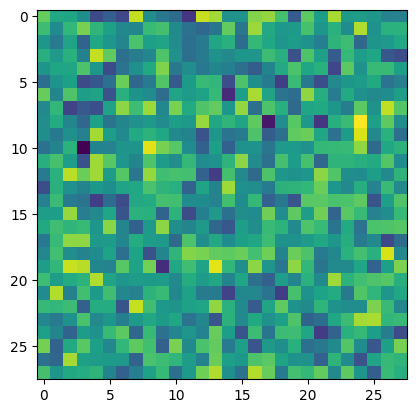

In [13]:
plt.imshow(all_images[0, :, :, :].squeeze().numpy())

In [14]:
# The size of the image is 28 by 28 and there are 3 color channels

In [15]:
filtered_images[0, :, :, :].shape

torch.Size([6, 28, 28])

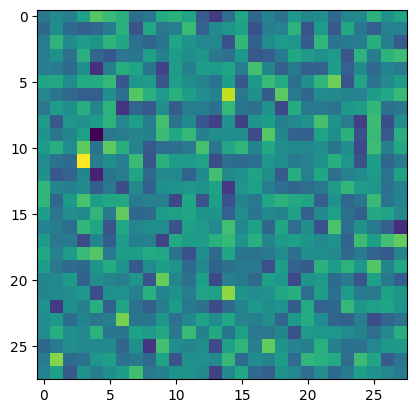

In [96]:
#@title {run:"auto"}
slider_value = 4 #@param {type:"slider", min:0, max:5}
plt.imshow(filtered_images[0, slider_value, :, :].detach().numpy())

In [17]:
# Let's increase strides to 2
conv_2d_filter_ = torch.nn.Conv2d(
    in_channels=1,
    out_channels=6,
    stride=2,
    padding=1,
    kernel_size=3
)

In [18]:
strides_2 = conv_2d_filter_(all_images)
print(strides_2.shape)

torch.Size([30, 6, 14, 14])


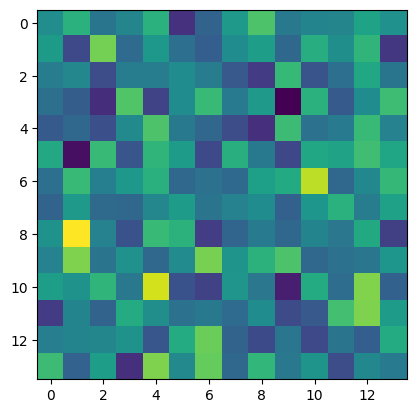

In [19]:
plt.imshow(strides_2[0, 1, :, :].squeeze().detach().numpy())

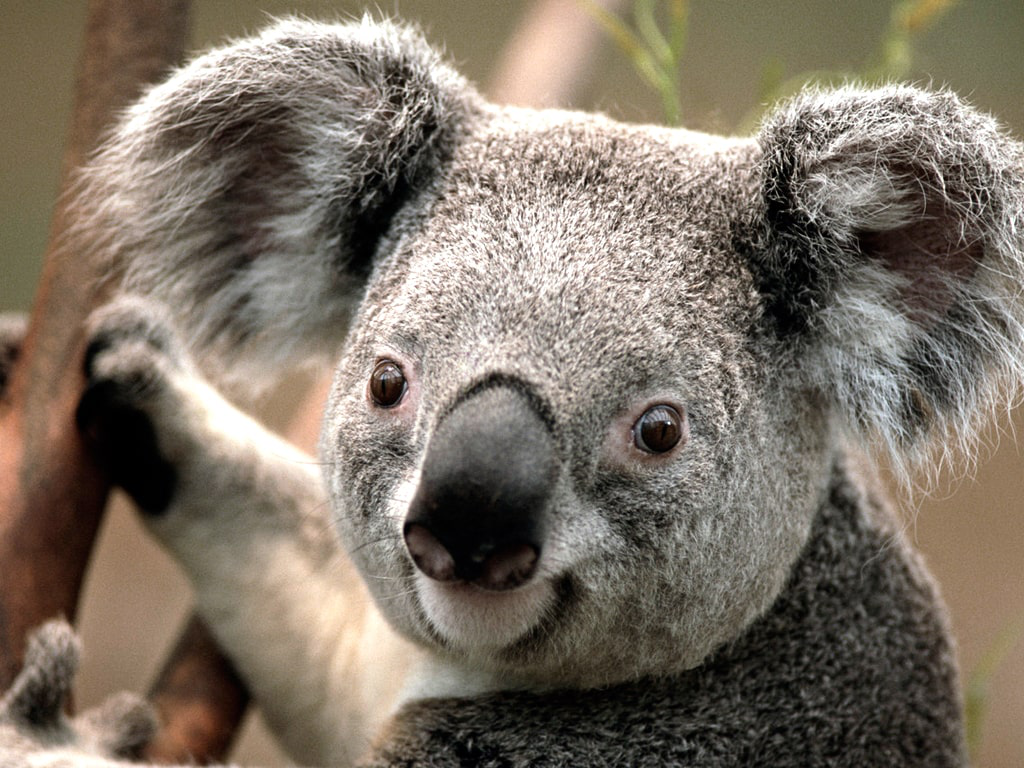

In [20]:
import skimage.io as io
img = Image.fromarray(io.imread('https://media.geeksforgeeks.org/wp-content/uploads/20210420115223/Koalainputimage.jpg'))
img

In [21]:
# filtered_koala_image = conv_2d_filter_(img)
# print(filtered_koala_image.shape)

In [22]:
# Whoops, we can't just apply the filter to the image,
# The image is in PIL format and it needs to be processed and transformed first

In [23]:
print(type(img))

<class 'PIL.Image.Image'>


In [24]:
import numpy as np
pil_to_array = np.array(img)
print(pil_to_array.shape)

(768, 1024, 3)


In [25]:
# Height = 768
# Width = 1024
# Channels = 3
print(type(pil_to_array))

<class 'numpy.ndarray'>


In [26]:
# Convert numpy array to tensor
numpy_to_tensor = torch.tensor(pil_to_array)
print(numpy_to_tensor.shape)
print(type(numpy_to_tensor))

torch.Size([768, 1024, 3])
<class 'torch.Tensor'>


In [37]:
# Reshape this tensor to match the input of our conv_2d_filter
# NCHW
# Number of images N (Batch) - here 1 image
# Number of channels - C 3
# Height and Width
# Here we are following the format of Image PIL object
# reshaped_image = numpy_to_tensor.view(1, 3, 768, 1024)
reshaped_image = numpy_to_tensor.view(1, 768, 1024, 3)
print(reshaped_image.shape)

torch.Size([1, 768, 1024, 3])


In [38]:
# Let's see the reshaped image
# squeeze operation result
# Yeah, as we squeeze() any shape elements which are of size 1 are removed
print(reshaped_image.squeeze().shape)
print(reshaped_image.squeeze().numpy().shape)
print(type(reshaped_image.squeeze().numpy()))
# Image.fromarray(
#     reshaped_image.squeeze().numpy()
# )

torch.Size([768, 1024, 3])
(768, 1024, 3)
<class 'numpy.ndarray'>


In [39]:
# io_read_image = io.imread('https://media.geeksforgeeks.org/wp-content/uploads/20210420115223/Koalainputimage.jpg')
# print(type(io_read_image))
# print(io_read_image.shape)

In [43]:
reshaped_squeezed_image = reshaped_image.squeeze().numpy()
print(reshaped_squeezed_image.shape)
print(type(reshaped_squeezed_image))
img_reshaped = Image.fromarray(reshaped_squeezed_image)
print(type(img_reshaped))

(768, 1024, 3)
<class 'numpy.ndarray'>
<class 'PIL.Image.Image'>


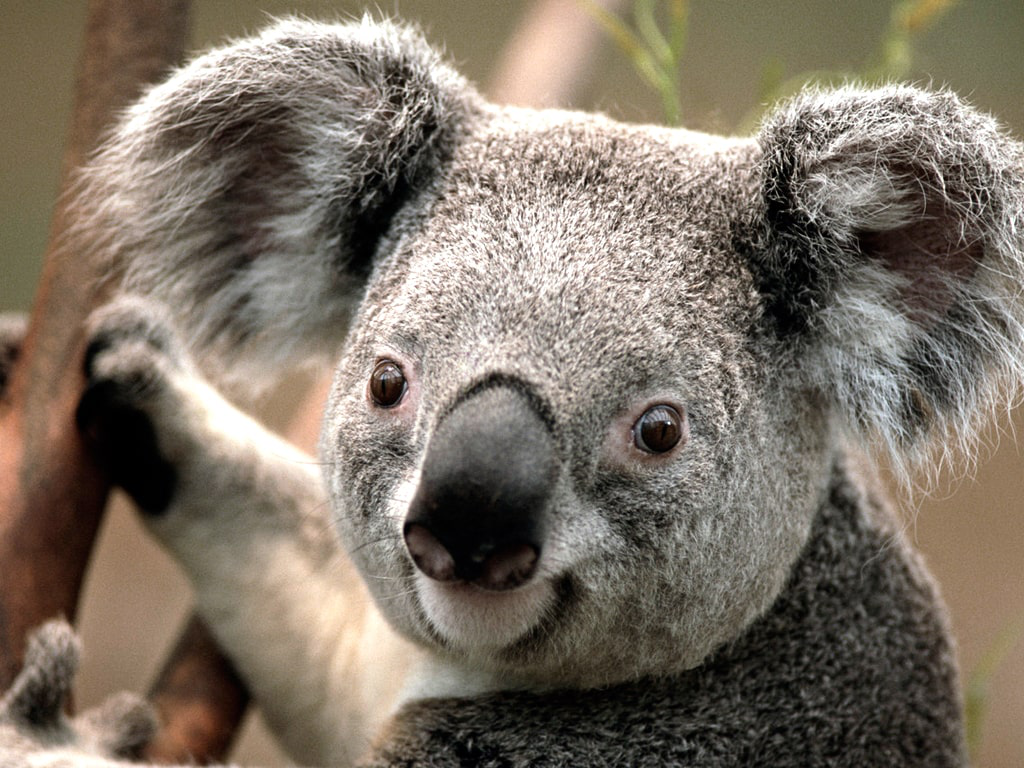

In [44]:
img_reshaped

In [45]:
# yeah, now it worked, awesome

In [97]:
# Let's use torch vision transformers
import torchvision.transforms as transforms
image_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        # transforms.Resize(
        #     (1048, 1048) # Resize to a square shape
        # )
    ]
)

# Apply transforms
img_transformed = image_transform(img_reshaped)
print(img_transformed.shape)

torch.Size([3, 768, 1024])


In [98]:
image_tensor = img_transformed.unsqueeze(0)
print(image_tensor.shape)

torch.Size([1, 3, 768, 1024])


In [99]:
# Let's create a conv2D filter for input channels=3
conv2d_3_channels = torch.nn.Conv2d(
    in_channels=3,
    out_channels=48,
    stride=1,
    kernel_size=3,
    padding=1
)
print(conv2d_3_channels)

Conv2d(3, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


In [100]:
koala_conv_filter = conv2d_3_channels(img_transformed)
print(koala_conv_filter.shape)

torch.Size([48, 768, 1024])


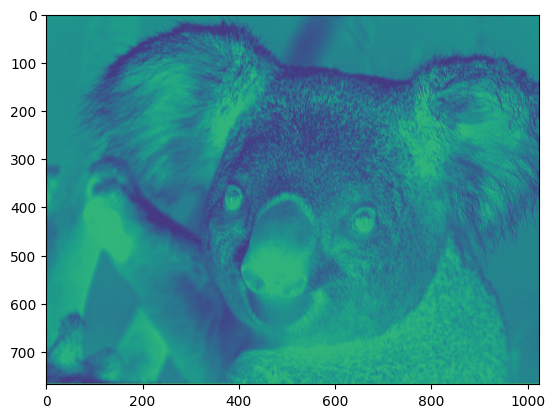

In [103]:
# I am creating a slider now
# Sinze we created 48 new filters,
# let's see what each filter is extracting from the image

# How to create a slide?
# @title {run: 'auto'}
slider_value = 16 # @param {type:'slider', min: 0, max: 47}

plt.imshow(koala_conv_filter.detach().numpy()[slider_value])

In [104]:
# Hmm.. the image doesn't need to be a square image
# Image can be in it's original shape
# The filter can still be applied, the output image will also be of input size
# For NN purposes, and consistency with other images
# we are resizing all images to a square format